# * Healthcare Appointment No-Show Prediction

## * Problem Statement

Healthcare appointment no-shows can lead to inefficient use of hospital
resources, longer waiting times, and reduced availability of appointments
for other patients.

This project aims to analyze healthcare appointment data to identify
patterns and factors associated with patients attending or missing their
scheduled appointments.

The analysis focuses on patient demographics, health conditions,
appointment details, waiting time, and SMS reminders.

Exploratory Data Analysis and Statistical Testing are used to identify
important patterns and relationships in appointment attendance.

## * Objectives

1. Understand the healthcare appointment dataset.
2. Clean and prepare the data for analysis.
3. Create useful features from the existing data.
4. Perform Exploratory Data Analysis (EDA).
5. Apply statistical tests to identify significant relationships.
6. Create an interactive Power BI dashboard.
7. Present key findings and recommendations.

📌 📚 1. IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


📌 📂 2. LOAD DATASET

In [5]:
#data load
df = pd.read_csv("/Users/kanizfatima/Documents/healthcare_noshows_appt 2.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


📌 📊 3. DATA UNDERSTANDING

In [6]:
# Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 106987
Columns: 15


In [7]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [8]:
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
106982,2.572134e+12,5651768,F,2016-05-03,2016-06-07,56,MARIA ORTIZ,False,False,False,False,False,True,True,35
106983,3.596266e+12,5650093,F,2016-05-03,2016-06-07,51,MARIA ORTIZ,False,False,False,False,False,True,True,35
106984,1.557663e+13,5630692,F,2016-04-27,2016-06-07,21,MARIA ORTIZ,False,False,False,False,False,True,True,41
106985,9.213493e+13,5630323,F,2016-04-27,2016-06-07,38,MARIA ORTIZ,False,False,False,False,False,True,True,41
106986,3.775115e+14,5629448,F,2016-04-27,2016-06-07,54,MARIA ORTIZ,False,False,False,False,False,True,True,41


In [9]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Showed_up', 'Date.diff']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  str    
 3   ScheduledDay    106987 non-null  str    
 4   AppointmentDay  106987 non-null  str    
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  str    
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
dtypes: bool(7), float64(1), int64(3), str(4)
memory usage: 7.2 MB


In [11]:
df.describe()

,PatientId,AppointmentID,Age,Date.diff
count,1.069870e+05,1.069870e+05,106987.000000,106987.000000
mean,1.472814e+14,5.675434e+06,38.316085,10.166721
std,2.558267e+14,7.133274e+04,22.466214,15.263508
min,3.921784e+04,5.030230e+06,1.000000,-6.000000
25%,4.173523e+12,5.640490e+06,19.000000,0.000000
50%,3.172463e+13,5.680744e+06,38.000000,4.000000
75%,9.433600e+13,5.725634e+06,56.000000,14.000000
max,9.999816e+14,5.790484e+06,115.000000,179.000000


In [12]:
df.describe(include="object")

,Gender,ScheduledDay,AppointmentDay,Neighbourhood
count,106987,106987,106987,106987
unique,2,110,27,81
top,F,2016-05-03,2016-06-06,JARDIM CAMBURI
freq,70118,4076,4528,7586


In [13]:
print(df["Showed_up"].value_counts())

Showed_up
True     85307
False    21680
Name: count, dtype: int64


In [14]:
print(
    df["Showed_up"].value_counts(normalize=True) * 100
)

Showed_up
True     79.735856
False    20.264144
Name: proportion, dtype: float64


📊 Data Understanding Summary
✔ Dataset contains 106,987 rows and 15 columns
✔ Includes patient details, appointment dates, and health conditions
✔ Target variable (Showed_up) shows appointment attendance
✔ Age ranges from 1 to 115 years
✔ SMS and health factors available for analysis
✔ Dataset is ready for cleaning and further analysis

📌 🧹 4. DATA CLEANING

In [15]:
# Missing values
print(df.isnull().sum())

df.dropna(inplace=True)


PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
Showed_up         0
Date.diff         0
dtype: int64


In [16]:
# Duplicates
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [17]:
# Date conversion
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce')

In [18]:
# Convert boolean columns
cols = ['Scholarship','Hipertension','Diabetes','Alcoholism','Handcap','SMS_received']

for col in cols:
    df[col] = df[col].astype(int)

# Convert target
df['Showed_up'] = df['Showed_up'].astype(int)

In [19]:
# Remove negative waiting days
df = df[df['Date.diff'] >= 0]

# Remove invalid age
df = df[df['Age'] >= 0]

In [20]:
print("Final Shape:", df.shape)
print("Missing:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Final Shape: (106982, 15)
Missing:
 PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
Showed_up         0
Date.diff         0
dtype: int64
Duplicates: 0


## Data Cleaning Summary

- No missing values found / handled
- Duplicate records removed
- Date columns converted into datetime format
- Boolean columns converted into numeric format
- Target variable standardized
- Invalid values removed (negative waiting days, age)

📌 ⚙️ 5. FEATURE ENGINEERING

In [21]:
# ============================================
# 5. FEATURE ENGINEERING
# ============================================

# 1. Waiting Days
df['Waiting_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

print("Waiting Days Summary:")
print(df['Waiting_Days'].describe())


# 2. Appointment Day
df['Appointment_Day'] = df['AppointmentDay'].dt.day_name()

print("\nAppointment Day Distribution:")
print(df['Appointment_Day'].value_counts())


# 3. Age Group
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[-1, 12, 19, 35, 59, 120],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print("\nAge Group Distribution:")
print(df['Age_Group'].value_counts())

Waiting Days Summary:
count    106982.000000
mean         10.167290
std          15.263631
min           0.000000
25%           0.000000
50%           4.000000
75%          14.000000
max         179.000000
Name: Waiting_Days, dtype: float64

Appointment Day Distribution:
Appointment_Day
Wednesday    25089
Tuesday      24829
Monday       21902
Friday       18465
Thursday     16658
Saturday        39
Name: count, dtype: int64

Age Group Distribution:
Age_Group
Adult          36349
Young Adult    22591
Senior         21172
Child          17496
Teen            9374
Name: count, dtype: int64


## Feature Engineering Summary

To enhance analysis, new features were created:

- Waiting_Days: Time gap between scheduling and appointment
- Appointment_Day: Day of the week
- Age_Group: Categorized patient age

These features help identify patterns affecting appointment attendance.

📌 📊 6. EDA (EXPLORATORY DATA ANALYSIS)

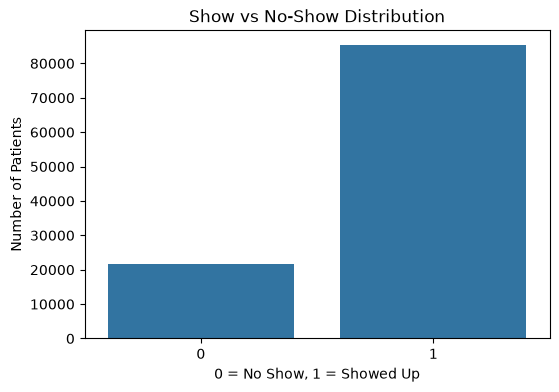

In [22]:
# ============================================
# EDA 1: Attendance Distribution
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Showed_up', data=df)

plt.title("Show vs No-Show Distribution")
plt.xlabel("0 = No Show, 1 = Showed Up")
plt.ylabel("Number of Patients")

plt.show()

## Attendance Distribution

This graph shows the number of patients who attended vs missed appointments.

It helps in understanding the overall no-show problem.

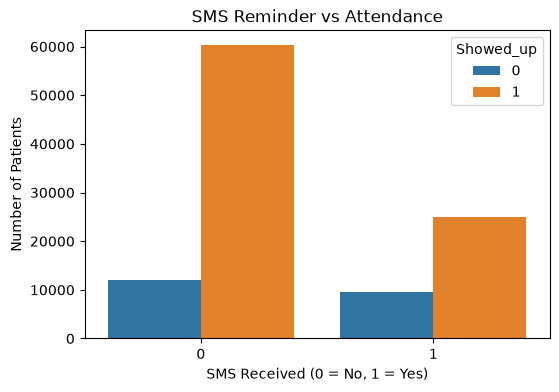

In [23]:
# ============================================
# EDA 2: SMS vs Attendance
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x='SMS_received', hue='Showed_up', data=df)

plt.title("SMS Reminder vs Attendance")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

## SMS Reminder vs Attendance

This graph shows the relationship between SMS reminders and appointment attendance.

It helps in understanding whether reminders improve patient attendance.

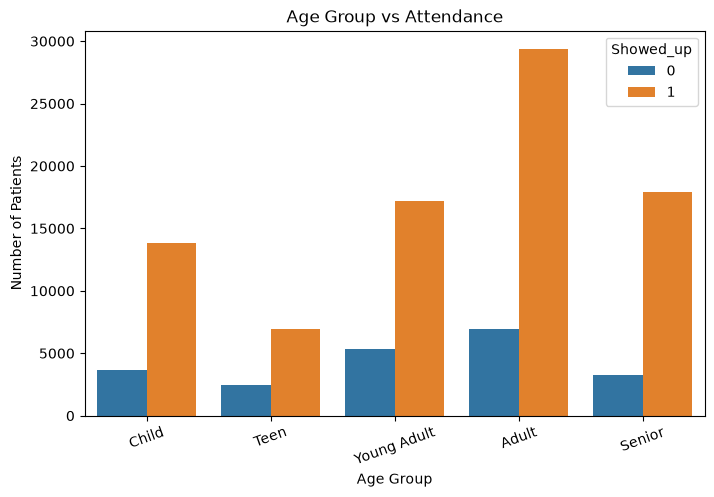

In [24]:
# ============================================
# EDA 3: Age Group vs Attendance
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(x='Age_Group', hue='Showed_up', data=df)

plt.title("Age Group vs Attendance")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.show()

## Age Group vs Attendance

This graph shows how appointment attendance varies across different age groups.

It helps identify which age groups are more likely to miss appointments.

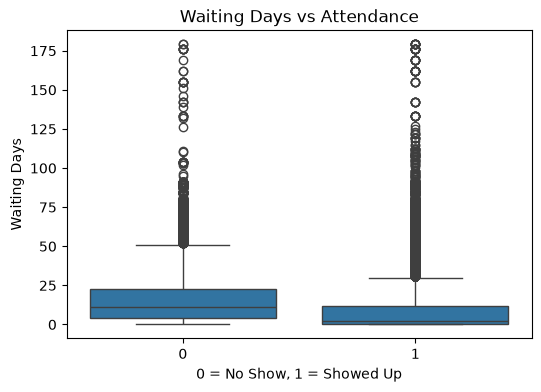

In [25]:
# ============================================
# EDA 4: Waiting Days vs Attendance
# ============================================

plt.figure(figsize=(6,4))

sns.boxplot(x='Showed_up', y='Waiting_Days', data=df)

plt.title("Waiting Days vs Attendance")
plt.xlabel("0 = No Show, 1 = Showed Up")
plt.ylabel("Waiting Days")

plt.show()

## Waiting Days vs Attendance

This graph shows the relationship between waiting time and appointment attendance.

It helps identify whether longer waiting periods increase the chances of no-shows.

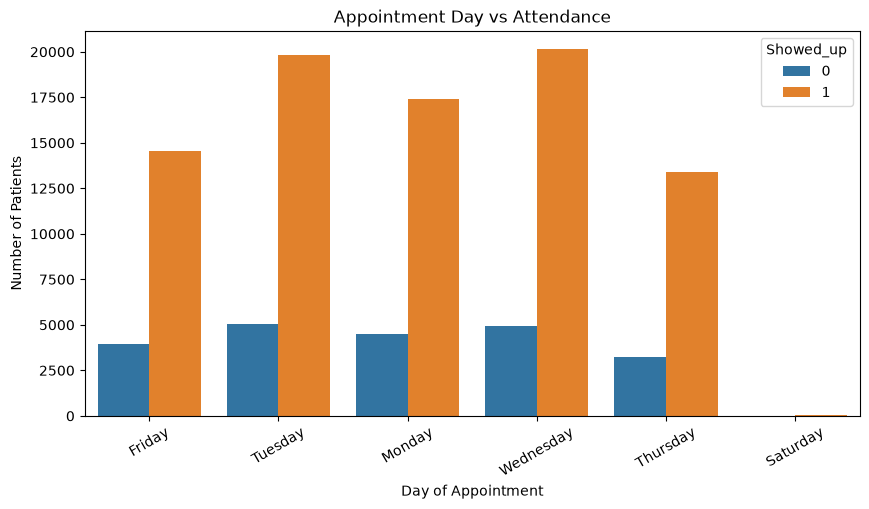

In [26]:
# ============================================
# EDA 5: Appointment Day vs Attendance
# ============================================

plt.figure(figsize=(10,5))

sns.countplot(x='Appointment_Day', hue='Showed_up', data=df)

plt.title("Appointment Day vs Attendance")
plt.xlabel("Day of Appointment")
plt.ylabel("Number of Patients")

plt.xticks(rotation=30)

plt.show()

## Appointment Day vs Attendance

This graph shows how appointment attendance varies across different days of the week.

It helps identify if certain days have higher no-show rates.

📌 📈 7. STATISTICAL TESTING

In [37]:
#📌 Chi-Square Test (SMS vs Attendance)

from scipy.stats import chi2_contingency

# Contingency table
sms_table = pd.crosstab(df["SMS_received"], df["Showed_up"])

print("Contingency Table:")
display(sms_table)

# Chi-square test
chi2_stat, p_sms, dof, expected = chi2_contingency(sms_table)

print("Chi-Square Statistic:", chi2_stat)
print("P-value:", p_sms)

# Decision
if p_sms < 0.05:
    print("Conclusion: SMS and attendance are SIGNIFICANTLY related")
else:
    print("Conclusion: No significant relationship")


Contingency Table:


Showed_up,0,1
SMS_received,,
0,12107,60290
1,9568,25017


Chi-Square Statistic: 1733.8334328645562
P-value: 0.0
Conclusion: SMS and attendance are SIGNIFICANTLY related


## Chi-Square Test

This test checks whether SMS reminders and appointment attendance are related.

If p-value < 0.05 → significant relationship exists.

In [38]:
#📌 T-Test (Age vs Attendance)

from scipy.stats import ttest_ind

age_show = df[df["Showed_up"] == 1]["Age"]
age_no_show = df[df["Showed_up"] == 0]["Age"]

t_age, p_age = ttest_ind(age_show, age_no_show, equal_var=False)

print("T-statistic:", t_age)
print("P-value:", p_age)

if p_age < 0.05:
    print("Conclusion: Age significantly affects attendance")
else:
    print("Conclusion: No significant difference in age")

T-statistic: 22.677792100870278
P-value: 4.866778458717665e-113
Conclusion: Age significantly affects attendance


## T-Test (Age vs Attendance)

This test checks whether the average age differs between patients who showed up and those who did not.

If p-value < 0.05 → significant difference exists.

In [39]:
#📌 T-Test (Waiting Days vs Attendance)

wait_show = df[df["Showed_up"] == 1]["Waiting_Days"]
wait_no_show = df[df["Showed_up"] == 0]["Waiting_Days"]

t_wait, p_wait = ttest_ind(wait_show, wait_no_show, equal_var=False)

print("T-statistic:", t_wait)
print("P-value:", p_wait)

if p_wait < 0.05:
    print("Conclusion: Waiting time significantly affects attendance")
else:
    print("Conclusion: No significant difference in waiting time")

T-statistic: -57.18798157240292
P-value: 0.0
Conclusion: Waiting time significantly affects attendance


## T-Test (Waiting Days vs Attendance)

This test checks whether waiting time affects appointment attendance.

If p-value < 0.05 → waiting time has strong impact.

In [40]:
# ============================================
# FINAL STATISTICAL SUMMARY
# ============================================

results = pd.DataFrame({
    "Test": [
        "Chi-Square (SMS vs Attendance)",
        "T-Test (Age vs Attendance)",
        "T-Test (Waiting Days vs Attendance)"
    ],
    
    "Statistic": [
        chi2_stat,
        t_age,
        t_wait
    ],
    
    "P-Value": [
        p_sms,
        p_age,
        p_wait
    ]
})

results["Significant (<0.05)"] = results["P-Value"] < 0.05

display(results)

,Test,Statistic,P-Value,Significant (<0.05)
0,Chi-Square (SMS vs Attendance),1733.833433,0.000000e+00,True
1,T-Test (Age vs Attendance),22.677792,4.866778e-113,True
2,T-Test (Waiting Days vs Attendance),-57.187982,0.000000e+00,True


## Final Statistical Conclusion

All statistical tests show significant results.

- SMS reminders significantly affect attendance.
- Age shows a statistically significant difference between groups.
- Waiting time has the strongest impact on appointment attendance.

Reducing waiting time and improving reminder systems can help reduce no-shows.

📌 💾 8. SAVE CLEAN DATASET

In [41]:
# FINAL STEP - SAVE CLEANED DATA

df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
